# Nearest Neighbors Classification


Adapted by <alberto.suarez@uam.es>

from
Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html#sphx-glr-auto-examples-neighbors-plot-classification-py

Version: Final

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets

# Plotting utilities
import utilities.plot_utilities as pltu

# <u>k-Nearest Neighbors (k-NN)</u>

The k-Nearest Neighbors (k-NN) algorithm is a supervised learning method that is non-parametric and instance-based. Unlike parametric models, k-NN does not learn an explicit decision function during training. Instead, the training phase consists solely of storing the labeled dataset, and all the computation is deferred to prediction time.

Let $\{(x_i, y_i)\}_{i=1}^N$ be a labeled training set, where $x_i \in \mathbb{R}^d$ denotes a feature vector and $y_i \in \{1,\dots,C\}$ its associated class label. Given a new input point $x \in \mathbb{R}^d$, the algorithm first computes a distance $d(x, x_i)$ between $x$ and every training sample, typically using the Euclidean metric. The $k$ samples with the smallest distances form the neighborhood $\mathcal{N}_k(x)$ of the point $x$. The predicted label for $x$ is then obtained by aggregating the labels of the points in $\mathcal{N}_k(x)$ according to a predefined voting rule.

In the simplest case, all neighbors contribute equally to the decision. This corresponds to uniform weighting, for which the predicted class is given by
$$
\hat{y}(x) = \arg\max_{c \in \{1,\dots,C\}}
\sum_{i \in \mathcal{N}_k(x)} \mathbf{1}_{\{y_i = c\}} .
$$
Alternatively, the contribution of each neighbor can be weighted by its distance to the query point, so that closer neighbors have a stronger influence on the classification. A common choice is inverse-distance weighting, leading to the decision rule
$$
\hat{y}(x) = \arg\max_{c \in \{1,\dots,C\}}
\sum_{i \in \mathcal{N}_k(x)} \frac{1}{d(x, x_i)} \, \mathbf{1}_{\{y_i = c\}} .
$$
This variant tends to produce decision boundaries that are more sensitive to the local structure of the data.

When k-NN is visualized in a two-dimensional feature space, the decision regions can be obtained by evaluating the classifier on a dense regular grid covering the domain of interest. Each grid point is treated as a new input and assigned a class using the k-NN rule. The resulting colored regions represent areas of the feature space that share the same predicted label, while the decision boundaries arise at locations where the majority class among the $k$ nearest neighbors changes. Importantly, these boundaries are not learned through optimization but emerge directly from the geometry and distribution of the training data.

The behavior of the k-NN classifier is largely governed by the choice of the hyperparameter $k$. Small values of $k$ lead to highly flexible decision boundaries with low bias and high variance, as the classification depends on very local information. Conversely, large values of $k$ produce smoother boundaries with higher bias and lower variance, as the decision incorporates information from a broader neighborhood. Overall, k-NN provides an intuitive and conceptually simple approach to classification in which predictions are driven entirely by proximity relationships in the feature space.

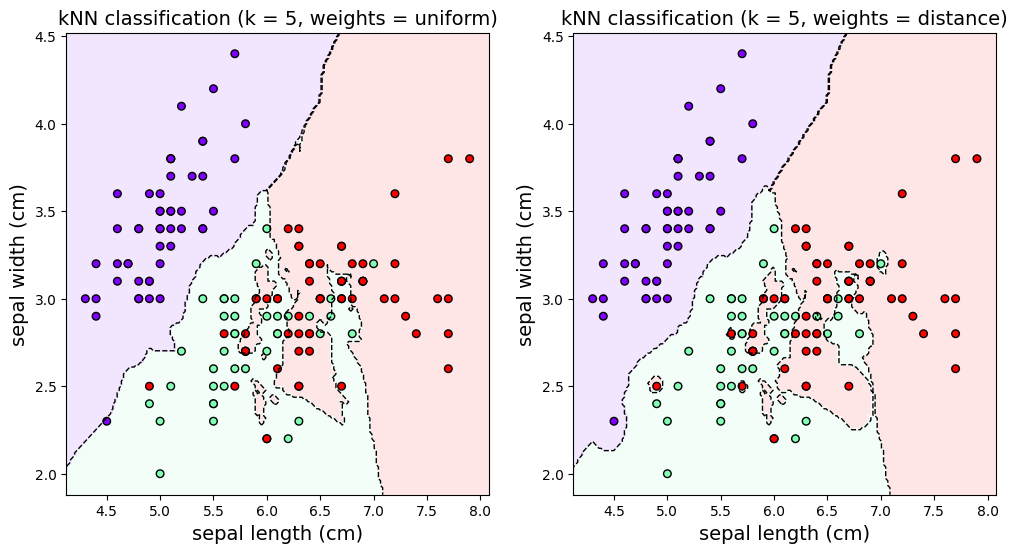

In [4]:
# Import a dataset.
dataset = datasets.load_iris()

# Consider only two features. 
indices_features = [0, 1]
X = dataset.data[:, indices_features]
y = dataset.target

n_classes = np.unique(y) # important not using magic numbers 

# Number of neighbors for kNN (k nearest neighbors).
n_neighbors = 5

nfig = 0
fontsize = 14    


fig, axs = plt.subplots(1,2, figsize=(12, 6))

for ax, weights in zip(axs, ['uniform', 'distance']): # en general se usan uniform. El parámetro importante es n_neighbors
        
    # Create an instance of a Neighbours Classifier
    # creamos un objeto de la clase KNeighborsClassifier
    classifier = neighbors.KNeighborsClassifier(n_neighbors, # n_neighbors es un hiperparámetro
                                                weights=weights)
    
    # Train the classifier using the data
    classifier.fit(X, y)
    
    # Plot the decision regions

    decision_function = classifier.predict 
   #  decision_function = classifier.predict_proba 

    pltu.plot_2D_decision_regions(X, y, 
                                  ax=ax,
                                  decision_function=decision_function,
                                  decision_levels='auto',
                                  cmap=plt.cm.rainbow) 
    
    ax.set_title('kNN classification (k = {}, weights = {})'.format(n_neighbors, weights), 
                 fontsize=fontsize)
    
    ax.set_xlabel(dataset.feature_names[indices_features[0]], 
              fontsize=fontsize)
    ax.set_ylabel(dataset.feature_names[indices_features[1]], 
              fontsize=fontsize)

---

## Exercises

1. Compare the results using different numbers of neighbors: [1, 7, 21, 101]
2. Compare the results using different $L_p$ (*Minkowski*) distances with p = [1, 2, np.inf]

### Exercise 1.

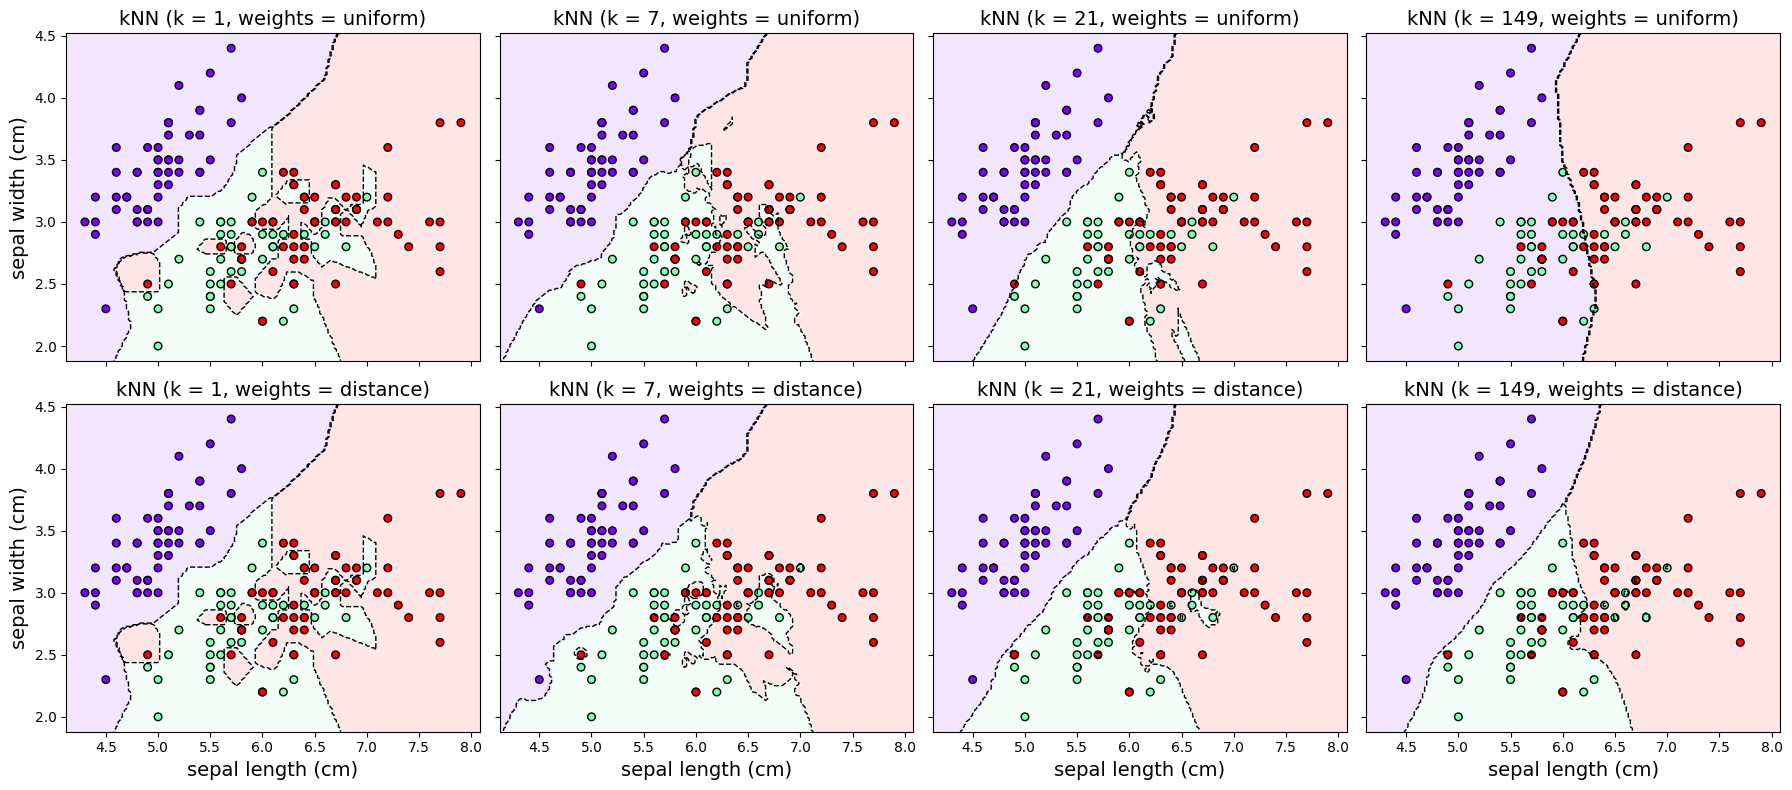

In [5]:
list_n_neighbors = [1, 7, 21, 149]
list_weights = ["uniform", "distance"]

fig, axs = plt.subplots(
    nrows=len(list_weights),
    ncols=len(list_n_neighbors),
    figsize=(18, 8),
    sharex=True,
    sharey=True,
)
axs = np.asarray(axs)

for i, weights in enumerate(list_weights):
    for j, neighbor in enumerate(list_n_neighbors):
        ax = axs[i, j]

        classifier = neighbors.KNeighborsClassifier(
            n_neighbors=neighbor,
            weights=weights,
        )
        classifier.fit(X, y)

        decision_function = classifier.predict  # or classifier.predict_proba

        pltu.plot_2D_decision_regions(
            X, y,
            ax=ax,
            decision_function=decision_function,
            decision_levels="auto",
            cmap=plt.cm.rainbow,
        )

        ax.set_title(f"kNN (k = {neighbor}, weights = {weights})", fontsize=fontsize)

        # Label axes only on left/bottom to reduce clutter
        if j == 0:
            ax.set_ylabel(dataset.feature_names[indices_features[1]], fontsize=fontsize)
        else:
            ax.set_ylabel("")
        if i == len(list_weights) - 1:
            ax.set_xlabel(dataset.feature_names[indices_features[0]], fontsize=fontsize)
        else:
            ax.set_xlabel("")

fig.tight_layout()

- `k` muy grande (en este caso `k`=149) tiende a ignorar la información de la x

- la complejidad del clasificador a medida que `k` aumenta, disminuye

- la distancia no depende del centrado pero sí del escalado

The figure illustrates how the decision regions produced by the k-Nearest Neighbors classifier evolve as a function of the number of neighbors $k$ and the weighting scheme used in the voting rule.

For small values of $k$ (e.g. $k=1$), the classifier relies on extremely local information. As a consequence, the decision boundaries are highly irregular and closely follow individual data points. This behavior reflects low bias but high variance: the model is very sensitive to noise and to isolated samples, leading to fragmented regions and sharp boundary fluctuations. Using distance-based weights in this regime slightly moderates this effect, as closer neighbors dominate the decision, but the classifier remains strongly local.

As $k$ increases to intermediate values (e.g. $k=7$ or $k=21$), the decision regions become smoother and more stable. The classifier aggregates information from a larger neighborhood, reducing sensitivity to individual points while still preserving the main geometric structure of the data. In this regime, the difference between uniform and distance-based weights is visible mainly near class overlaps: distance weighting tends to produce more locally adaptive boundaries, whereas uniform weighting yields smoother, more averaged transitions.

The extreme case $k=149$ with uniform weights is particularly instructive. Here, $k$ is comparable to the total number of samples, so each prediction effectively depends on almost the entire dataset. The classifier behaves close to a global majority-vote rule, largely ignoring local structure. As a result, the decision boundary becomes very smooth and nearly linear, reflecting a strong bias and very low variance. Local clusters and finer class distinctions are washed out, and the predicted class at most locations is dominated by the globally most frequent labels. This illustrates the limiting behavior of k-NN: as $k \to N$ with uniform weighting, the classifier loses its local, nonparametric character and approaches a global classifier driven by class proportions.

Overall, the figure highlights the bias–variance trade-off inherent in k-NN. Small $k$ emphasizes locality at the cost of stability, while large $k$, especially with uniform weights, enforces strong smoothing and sacrifices local detail in favor of global consistency.

### Exercise 2:

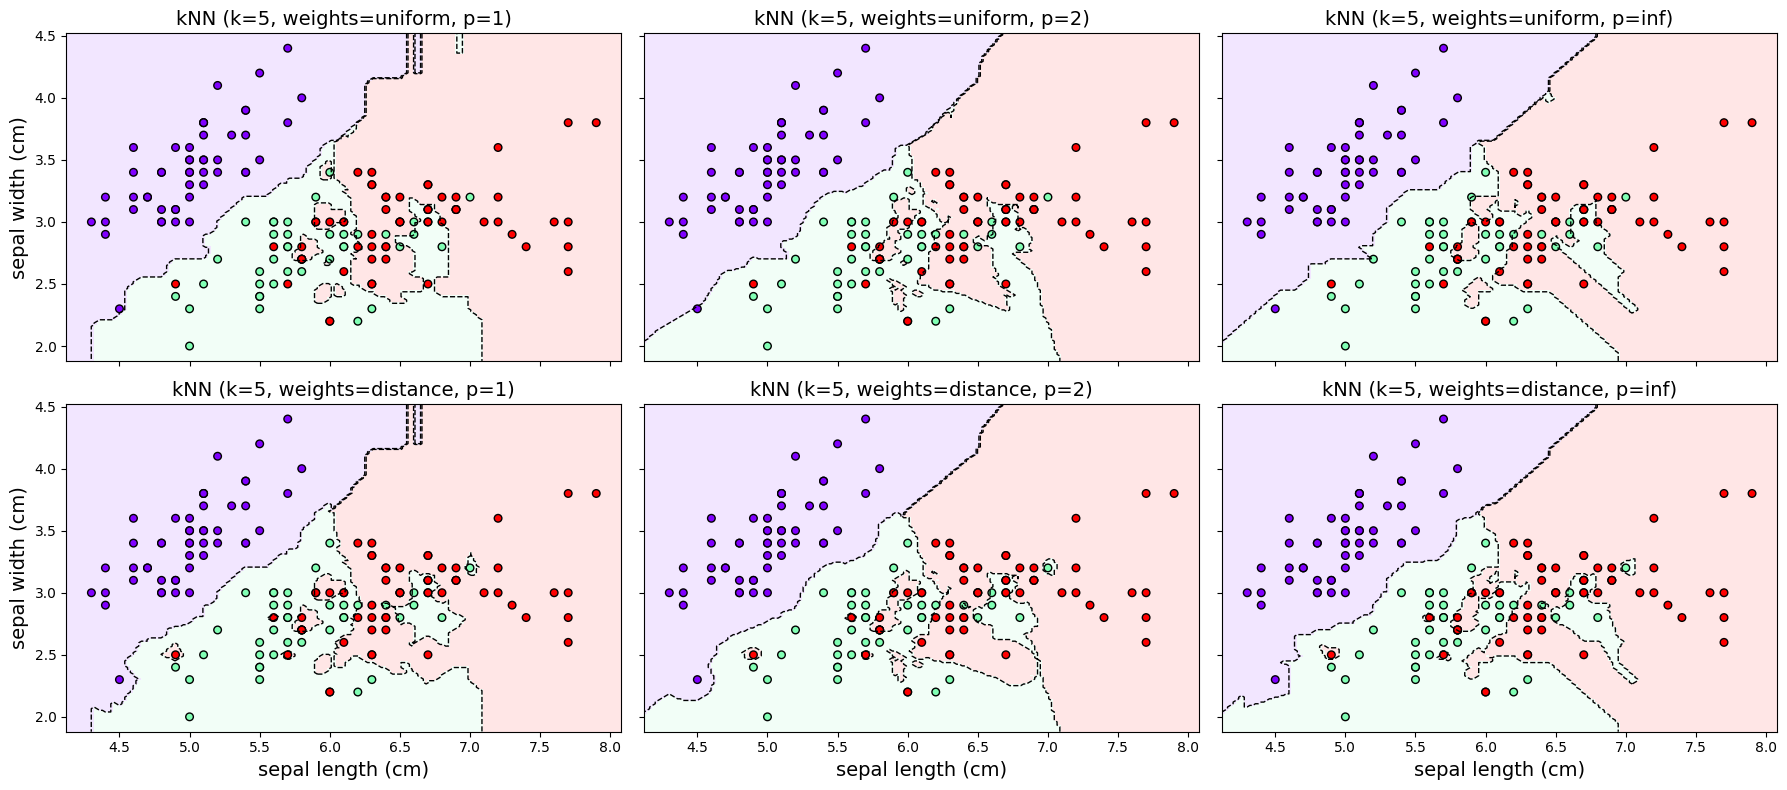

In [7]:
p_list = [1, 2, np.inf]
weights_list = ["uniform", "distance"]

fig, axs = plt.subplots(
    nrows=len(weights_list),
    ncols=len(p_list),
    figsize=(18, 8),
    sharex=True,
    sharey=True,
)

axs = np.asarray(axs)

for i, weights in enumerate(weights_list):
    for j, p in enumerate(p_list):
        ax = axs[i, j]

        classifier = neighbors.KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            p=p,
        )
        classifier.fit(X, y)

        decision_function = classifier.predict
        # decision_function = classifier.predict_proba

        pltu.plot_2D_decision_regions(
            X, y,
            ax=ax,
            decision_function=decision_function,
            decision_levels="auto",
            cmap=plt.cm.rainbow,
        )

        ax.set_title(
            f"kNN (k={n_neighbors}, weights={weights}, p={p})",
            fontsize=fontsize,
        )

        # Etiquetas solo donde aporta información
        if i == len(weights_list) - 1:
            ax.set_xlabel(dataset.feature_names[indices_features[0]], fontsize=fontsize)
        else:
            ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel(dataset.feature_names[indices_features[1]], fontsize=fontsize)
        else:
            ax.set_ylabel("")

fig.tight_layout()

The figure illustrates the impact of the distance metric, controlled by the parameter $p$, on the decision regions of the k-Nearest Neighbors classifier, for a fixed number of neighbors ($k=5$) and for both uniform and distance-based weighting schemes.

When $p=1$, the classifier uses the Manhattan (ℓ₁) distance. In this case, distances are accumulated along coordinate directions, which leads to decision boundaries that tend to align more closely with the axes of the feature space. As a result, the regions often exhibit sharper corners and less isotropic shapes, reflecting the geometry induced by the ℓ₁ norm. This effect is visible for both weighting schemes, although distance weighting slightly smooths the boundaries by emphasizing the closest neighbors.

For $p=2$, corresponding to the Euclidean (ℓ₂) distance, the metric becomes rotationally invariant. The neighborhoods are more isotropic, and the resulting decision boundaries appear smoother and more rounded. This choice typically provides a balanced compromise between locality and geometric regularity, which explains why it is the most commonly used metric in practice. Differences between uniform and distance-based weights are again most apparent near regions of class overlap.

In the limit $p \to \infty$, the distance reduces to the Chebyshev (ℓ∞) metric, where the distance between two points is determined by the largest coordinate-wise difference. This induces neighborhoods with square-like geometry aligned with the axes. Consequently, the decision regions become more constrained by extreme feature differences, and the boundaries tend to straighten and align with dominant directions in the data. Local variations are still present, but the influence of the most dissimilar feature dominates the notion of proximity.

Overall, the figure highlights that the choice of $p$ directly shapes the geometry of neighborhoods in feature space and, therefore, the form of the decision boundaries. While the weighting scheme controls how strongly local information is emphasized, the parameter $p$ determines what “closeness” means, making it a fundamental modeling choice in k-NN classification.

## To explore:
https://scikit-learn.org/stable/modules/neighbors.html#